# HW3P3 — First data pipeline

**Your name:**

**Kaggle dataset URL:**

In this notebook, you will download a real Kaggle dataset, load it, inspect it, handle missing values, and perform a meaningful grouping or filter. Complete each `# TODO` section.

In [2]:
# Setup: import pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt

# If you need to install kaggle from PyPI, uncomment the line below.
!pip install kaggle

## Task 1: Load a Kaggle dataset

Download a real dataset from Kaggle (https://www.kaggle.com/datasets). You have two options:

1. **Manual download:** Download the CSV file from Kaggle and upload it to Colab.
2. **Kaggle CLI:** If you have set up Kaggle authentication, use the CLI to download directly.

Below is a scaffold for loading from a local file. Modify the filename to match your dataset.

In [29]:
# TODO: Replace 'dataset_name.csv' with your actual dataset filename.
# Example: df = pd.read_csv('penguins.csv')
# Or, if using Kaggle CLI: !kaggle datasets download -d <dataset-name> && unzip <dataset-name>.zip

import pandas as pd
import os

df = pd.read_csv('movies_dataset.csv')



## Task 2: Inspect the dataset

Get a sense of your data: print the shape, column names, data types, and a summary of missing values.

In [23]:
# TODO: Print shape, column info, and missing values.
# Hints: use df.shape, df.info(), df.isnull().sum()

print("Dataset shape:", df.shape)
print("\nColumn info:")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (208480, 17)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208480 entries, 0 to 208479
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   MovieID               208480 non-null  int64  
 1   Title                 208480 non-null  object 
 2   Genre                 208479 non-null  object 
 3   ReleaseYear           208479 non-null  float64
 4   ReleaseDate           208479 non-null  object 
 5   Country               208479 non-null  object 
 6   BudgetUSD             208479 non-null  float64
 7   US_BoxOfficeUSD       208479 non-null  float64
 8   Global_BoxOfficeUSD   208479 non-null  float64
 9   Opening_Day_SalesUSD  208479 non-null  float64
 10  One_Week_SalesUSD     208479 non-null  float64
 11  IMDbRating            208479 non-null  float64
 12  RottenTomatoesScore   208479 non-null  float64
 13  NumVotesIMDb          208479 non-null  float64
 14  NumVotesRT

## Task 3: Handle a missing-value issue

Identify one column with missing values and decide how to handle it. You may:
- **Fill** with mean (numeric) or median (numeric) or a sensible default (categorical)
- **Drop rows** containing the missing value
- **Drop the column** entirely

Justify your choice in the Markdown cell below, then apply the fix.

### My missing-value strategy

There are many columns in the dataset that have a missing value; I have chosen to focus on the missing Rotten Tomatoes Score. I will drop the row with the missing value, as there is a large enough sample size that dropping the row should not significantly impact the data.

In [24]:
# TODO: Handle missing values in one column.
# Example (uncomment and modify):

df = df.dropna(subset=['RottenTomatoesScore'])

# Verify that the fix worked:
print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
MovieID                 0
Title                   0
Genre                   0
ReleaseYear             0
ReleaseDate             0
Country                 0
BudgetUSD               0
US_BoxOfficeUSD         0
Global_BoxOfficeUSD     0
Opening_Day_SalesUSD    0
One_Week_SalesUSD       0
IMDbRating              0
RottenTomatoesScore     0
NumVotesIMDb            0
NumVotesRT              0
Director                0
LeadActor               0
dtype: int64


## Task 4: Group or filter by a meaningful column

Choose one column in your dataset and either:
- **Group by it** and compute an aggregate (mean, count, sum, std, etc.)
- **Filter to it** and show rows matching a condition

Explain why this grouping or filter makes sense for your data.

### Why I grouped/filtered by this column

I grouped the data set by lead actor and calculated the mean Rotten Tomatoes Score. I was curious if any lead actors had a higher average Rotten Tomatoes score than others.

              LeadActor  mean_RTScore
0           Adam Bowman     64.802152
1           Adam Montes     64.598501
2         Adam Williams     64.799231
3          Alan Mullins     64.207264
4       Alexander Haley     65.120705
..                  ...           ...
294      William Brooks     64.520244
295    William Crawford     64.472156
296      William Prince     64.976944
297     William Ramirez     65.073865
298  William Washington     65.218127

[299 rows x 2 columns]


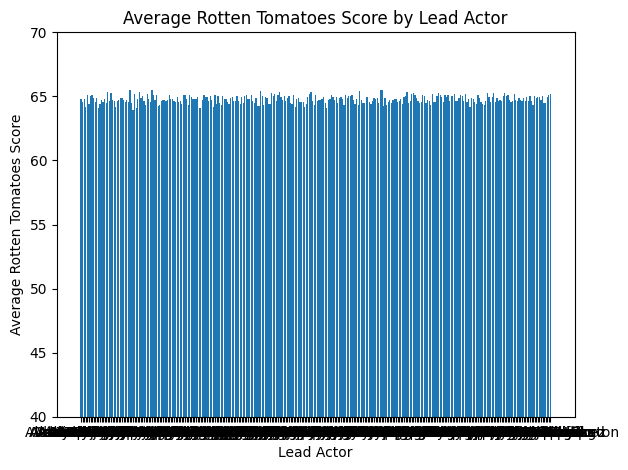

In [55]:
# TODO: Perform a groupby or filter operation.
# Example (groupby):
grouped = df.groupby('LeadActor').agg(
  mean_RTScore = ('RottenTomatoesScore', 'mean')
).reset_index()
print(grouped)

import matplotlib.pyplot as plt
plt.bar(grouped['LeadActor'], grouped['mean_RTScore'])
plt.xlabel('Lead Actor')
plt.ylabel('Average Rotten Tomatoes Score')
plt.title('Average Rotten Tomatoes Score by Lead Actor')
plt.ylim(40, 70)
plt.tight_layout()
plt.figsize = (200, 5)
plt.show()

## Task 5: Summary and insights

Write a final reflection on your analysis: what does your dataset represent, why did you handle missing values the way you did, and what does your grouping or filter reveal?

### My analysis summary

Write 3–5 sentences summarizing:
1. My dataset is about ratings, sales, and other details of movies from 1950 through 2025.
2. The missing-value issue you found and why your strategy was appropriate.
I found a missing value in most columns, including the Rotten Tomatoes Score; this would cause an issue when calculating the average score. I dropped this row, as there is a very large sample size, so the calculations should still be representative.
3. I grouped the data by lead actor, to see if there is a correlation between lead actor and average Rotten Tomatoes score; the data showed that the average Rotten Tomatoes score is consistent between lead actors, falling around 64%.